# Multi-Terrain Evaluation Analysis

This notebook loads all CSV evaluation files for a selected approach from an experiment folder, computes metrics per terrain, and computes pooled metrics across all terrains.

Expected filename pattern:

```text
{approach}_{terrain}_{disturbance_condition}.csv
```

Example:

```text
pact_rough_payload.csv
pos_stairs_push.csv
tau_plane_none.csv
```

Set `EXP_FOLDER`, `APPROACH`, and optionally `DISTURBANCE_CONDITION` in the configuration cell below.


In [1]:
import os
import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

try:
    import seaborn as sns
except ImportError:
    sns = None


## Configuration

In [2]:
# --- User settings ---
EXP_FOLDER = "pact_lowerjointrand_strongtau/"
APPROACH = "go1_pact"

# Set to None to load every disturbance condition for this approach.
# Otherwise use strings like "none", "payload", "push", etc.
DISTURBANCE_CONDITION = None

# Optional output directory for result tables
RESULTS_DIR = Path(EXP_FOLDER) / "analysis_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Default target used for height tracking.
BASE_HEIGHT_TARGET = 0.30

# Optional constants used only for limit violation metrics.
# Expected shapes:
#   JOINT_LIMITS: [2, num_dofs], where row 0 is lower and row 1 is upper
#   JOINT_TORQUE_LIMITS: scalar or [num_dofs]
JOINT_LIMITS = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])
JOINT_TORQUE_LIMITS = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

EPS = 1e-8

EXCLUDE_DIRS = ["analysis_results"]

NUM_WORKERS = 20

## Loading utilities

In [3]:
def string_to_array(array_string):
    """Convert stringified list/array columns from the logger into Python lists."""
    if isinstance(array_string, str):
        try:
            return ast.literal_eval(array_string)
        except (ValueError, SyntaxError):
            return array_string
    return array_string


ARRAY_COLUMNS = [
    "base_cmd",
    "base_pose",
    "base_rpy",
    "dof_pose",
    "base_lin_vel",
    "base_ang_vel",
    "dof_vel",
    "proj_grav",
    "feet_pos",
    "tau_act",
    "grf",
    "q_des",
    "tau_ff",
    "tau_pd",
    "payload",
    "com_shift",
    "rand_push",
    "rand_wrench",
]


def get_csv_converters(columns=ARRAY_COLUMNS):
    return {col: string_to_array for col in columns}


def parse_eval_filename(path, approach):
    """
    Parse filenames of the form:
        {approach}_{terrain}_{disturbance_condition}.csv

    This assumes the terrain token comes immediately after the approach token.
    Everything after the terrain token is treated as the disturbance condition.
    """
    stem = Path(path).stem

    prefix = f"{approach}_"
    if not stem.startswith(prefix):
        return None

    remainder = stem[len(prefix):]
    parts = remainder.split("_")

    if len(parts) < 2:
        return None

    terrain = parts[0]
    disturbance_condition = "_".join(parts[1:])

    return {
        "approach": approach,
        "terrain": terrain,
        "disturbance_condition": disturbance_condition,
        "path": Path(path),
    }


def find_eval_files(exp_folder, approach, disturbance_condition=None):
    exp_folder = Path(exp_folder)

    records = []
    for path in sorted(exp_folder.rglob(f"{approach}_*.csv")):
        info = parse_eval_filename(path, approach)
        if info is None:
            continue

        # Skip blacklisted subdirectories
        if EXCLUDE_DIRS:
            rel_parts = path.relative_to(exp_folder).parts
            if any(part in EXCLUDE_DIRS for part in rel_parts):
                continue

        if disturbance_condition is not None:
            if info["disturbance_condition"] != disturbance_condition:
                continue

        records.append(info)

    return pd.DataFrame(records)


def load_eval_csv(path):
    """Load one evaluation CSV with logger array columns converted."""
    return pd.read_csv(path, converters=get_csv_converters())


def load_eval_dataset(file_table):
    """
    Load all files in file_table and concatenate them into one dataframe.

    Adds:
        approach
        terrain
        disturbance_condition
        source_file
    """
    dfs = []

    for _, row in file_table.iterrows():
        df = load_eval_csv(row["path"])

        df["approach"] = row["approach"]
        df["terrain"] = row["terrain"]
        df["disturbance_condition"] = row["disturbance_condition"]
        df["source_file"] = str(row["path"])

        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)


def _load_one_eval_file(row):
    df = load_eval_csv(row["path"])

    df["approach"] = row["approach"]
    df["terrain"] = row["terrain"]
    df["disturbance_condition"] = row["disturbance_condition"]
    df["source_file"] = str(row["path"])

    return df

def load_eval_dataset_parallel(file_table, max_workers=10):
    rows = [row for _, row in file_table.iterrows()]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        dfs = list(executor.map(_load_one_eval_file, rows))

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)

In [4]:
file_table = find_eval_files(
    EXP_FOLDER,
    APPROACH,
    disturbance_condition=DISTURBANCE_CONDITION,
)

file_table


,approach,terrain,disturbance_condition,path
0,go1_pact,discrete,none,pact_lowerjointrand_strongtau/no_disturbance/g...
1,go1_pact,plane,none,pact_lowerjointrand_strongtau/no_disturbance/g...
2,go1_pact,rough,none,pact_lowerjointrand_strongtau/no_disturbance/g...
3,go1_pact,slope,none,pact_lowerjointrand_strongtau/no_disturbance/g...
4,go1_pact,stairs,none,pact_lowerjointrand_strongtau/no_disturbance/g...
5,go1_pact,wave,none,pact_lowerjointrand_strongtau/no_disturbance/g...
6,go1_pact,discrete,payload,pact_lowerjointrand_strongtau/payload_disturba...
7,go1_pact,plane,payload,pact_lowerjointrand_strongtau/payload_disturba...
8,go1_pact,rough,payload,pact_lowerjointrand_strongtau/payload_disturba...
9,go1_pact,slope,payload,pact_lowerjointrand_strongtau/payload_disturba...


In [5]:
df_all = load_eval_dataset_parallel(file_table, max_workers=NUM_WORKERS)

print(f"Loaded {len(file_table)} files")
print(f"Loaded {len(df_all):,} rows")
print("Terrains:", sorted(df_all["terrain"].unique()))
print("Disturbance conditions:", sorted(df_all["disturbance_condition"].unique()))

df_all.head()


Loaded 18 files
Loaded 7,200,000 rows
Terrains: ['discrete', 'plane', 'rough', 'slope', 'stairs', 'wave']
Disturbance conditions: ['none', 'payload', 'push']


,Unnamed: 0,base_cmd,base_pose,base_rpy,dof_pose,base_lin_vel,base_ang_vel,dof_vel,proj_grav,feet_pos,...,tau_pd,failure,payload,com_shift,rand_push,rand_wrench,approach,terrain,disturbance_condition,source_file
0,0,"[-0.0960875153541565, -0.26534610986709595, 1....","[3.835923433303833, 3.892320156097412, 0.32936...","[0.0017967860912904143, 0.002046734793111682, ...","[-0.20724248886108398, 0.5779221653938293, -1....","[-0.4289476275444031, -0.18787871301174164, -0...","[0.09920161962509155, -0.0013931207358837128, ...","[2.1994731426239014, 4.75166654586792, -5.3688...","[0.0020467336289584637, -0.0017967808526009321...","[[4.055454254150391, 3.699167251586914, 0.0214...",...,"[2.9396660327911377, 5.918989181518555, -3.158...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,pact_lowerjointrand_strongtau/no_disturbance/g...
1,1,"[0.06778740882873535, 0.4088113307952881, 0.71...","[19.766189575195312, 4.427699565887451, 0.3324...","[0.026049640029668808, 0.005182262044399977, 0...","[0.12373198568820953, 1.0534898042678833, -1.4...","[-0.24332045018672943, -0.2628394067287445, -0...","[1.8692482709884644, 0.2737416625022888, 0.236...","[-2.685866355895996, -0.4623674154281616, -2.7...","[0.005182238295674324, -0.02604634128510952, -...","[[19.843751907348633, 4.347618103027344, 0.017...",...,"[-5.579106330871582, -6.6966447830200195, -2.5...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,pact_lowerjointrand_strongtau/no_disturbance/g...
2,2,"[-0.07134497165679932, 0.9602271318435669, 0.1...","[27.54875946044922, 3.6689324378967285, 0.3372...","[-0.006698469165712595, 0.002024888526648283, ...","[0.007229084149003029, 0.9998347759246826, -1....","[0.3483005166053772, 0.20519275963306427, -0.2...","[-0.6303231716156006, 0.21835744380950928, -0....","[-1.5508614778518677, -3.253938913345337, -3.0...","[0.002024887129664421, 0.006698405370116234, -...","[[27.631694793701172, 3.5423684120178223, 0.02...",...,"[-3.0969340801239014, -5.689051151275635, -3.7...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,pact_lowerjointrand_strongtau/no_disturbance/g...
3,3,"[0.08069193363189697, 0.3022540807723999, 0.27...","[27.905385971069336, 3.6168370246887207, 0.336...","[-0.02409612573683262, 0.001895543304271996, 0...","[-0.24735525250434875, 0.9575036764144897, -1....","[0.2726714313030243, -0.4300881624221802, -0.2...","[-1.6610302925109863, 0.273036926984787, 0.328...","[3.502533435821533, -1.7492495775222778, -5.43...","[0.0018955422565340996, 0.0240937527269125, -0...","[[27.98936653137207, 3.40665864944458, 0.04717...",...,"[3.866520404815674, -4.7619781494140625, -5.28...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,pact_lowerjointrand_strongtau/no_disturbance/g...
4,4,"[0.18676280975341797, -0.8427570462226868, 0.5...","[4.175797939300537, 4.077792644500732, 0.33329...","[0.008188683539628983, 0.008664079010486603, -...","[-0.20182593166828156, 0.9873773455619812, -1....","[0.46873366832733154, -0.046556103974580765, -...","[0.7058923244476318, 0.36849018931388855, -0.3...","[1.411249041557312, -3.911752223968506, 6.3350...","[0.008663970045745373, -0.008188284933567047, ...","[[4.307693958282471, 3.8957056999206543, 0.063...",...,"[0.5465425252914429, -2.827754497528076, 4.199...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,pact_lowerjointrand_strongtau/no_disturbance/g...


## Metric utilities

In [6]:
def as_array(df, column, valid_mask=None):
    """Convert a dataframe column of list-like entries into a numpy array."""
    if column not in df.columns:
        return None

    series = df[column]
    if valid_mask is not None:
        series = series.loc[valid_mask]

    if len(series) == 0:
        return None

    return np.asarray(series.to_list())


def safe_mean(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanmean(x))


def safe_std(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanstd(x))


def rmse(x):
    x = np.asarray(x)
    return float(np.sqrt(np.nanmean(np.square(x))))


def mae(x):
    x = np.asarray(x)
    return float(np.nanmean(np.abs(x)))


def mean_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanmean(np.linalg.norm(x, axis=axis, ord=1)))


def std_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanstd(np.linalg.norm(x, axis=axis, ord=1)))


def rpy_to_rotmat(rpy):
    """
    rpy: (..., 3) roll, pitch, yaw
    returns: (..., 3, 3) rotation matrix (base -> world)
    """
    roll, pitch, yaw = rpy[..., 0], rpy[..., 1], rpy[..., 2]

    cr, sr = np.cos(roll),  np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw),   np.sin(yaw)

    R = np.stack([
        np.stack([cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr], axis=-1),
        np.stack([sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr], axis=-1),
        np.stack([-sp,   cp*sr,            cp*cr           ], axis=-1)
    ], axis=-2)

    return R


In [7]:
def compute_eval_metrics(
    df,
    approach='pact',
    base_height_target=0.30,
    joint_limits=None,
    joint_torque_limits=None,
    pact_metric_approaches=("pact", "abl"),
    eps=1e-8,
):
    """
    Compute scalar evaluation metrics for one dataframe.

    Failed rows are excluded from continuous metrics but counted in failure statistics.
    """
    metrics = {}

    use_pact_metrics = (
        approach is not None
        and any(k.lower() in approach.lower() for k in pact_metric_approaches)
    )

    n_total = len(df)
    failure = df["failure"].astype(float).to_numpy() if "failure" in df.columns else np.zeros(n_total)
    valid_mask = failure == 0

    metrics["num_rows_total"] = int(n_total)
    metrics["num_rows_valid"] = int(valid_mask.sum())
    metrics["num_failures"] = int(failure.sum())
    metrics["failure_rate"] = float(failure.mean()) if n_total > 0 else np.nan

    if valid_mask.sum() == 0:
        return metrics

    q_actions = as_array(df, "q_des", valid_mask)
    q_obs = as_array(df, "dof_pose", valid_mask)

    vel_cmds = as_array(df, "base_cmd", valid_mask)
    lin_vel = as_array(df, "base_lin_vel", valid_mask)
    ang_vel = as_array(df, "base_ang_vel", valid_mask)

    base_pose = as_array(df, "base_pose", valid_mask)
    proj_grav = as_array(df, "proj_grav", valid_mask)

    q_vel = as_array(df, "dof_vel", valid_mask)
    q_tau = as_array(df, "tau_act", valid_mask)

    grfs = as_array(df, "grf", valid_mask)
    ff_tau = as_array(df, "tau_ff", valid_mask)
    pd_tau = as_array(df, "tau_pd", valid_mask)

    # Joint tracking
    if q_actions is not None and q_obs is not None:
        dof_errors = q_actions - q_obs
        metrics["dof_tracking_rmse"] = rmse(dof_errors)
        metrics["dof_tracking_mae"] = mae(dof_errors)
        metrics["q_action_norm_mean"] = mean_norm(q_actions)
        metrics["q_action_norm_std"] = std_norm(q_actions)

        if joint_limits is not None:
            joint_limits = np.asarray(joint_limits)
            joint_pred_limits_error = -(q_actions - joint_limits[0, :]).clip(max=0.0)
            joint_pred_limits_error += (q_actions - joint_limits[1, :]).clip(min=0.0)
            metrics["joint_limit_violation_mean"] = float(np.mean(joint_pred_limits_error))

    # Command tracking
    if vel_cmds is not None and lin_vel is not None and ang_vel is not None:
        lin_cmd_errors = vel_cmds[:, 0:2] - lin_vel[:, 0:2]
        ang_cmd_errors = vel_cmds[:, 2] - ang_vel[:, 2]
        cmd_errs = np.concatenate((lin_cmd_errors, ang_cmd_errors[:, None]), axis=1)

        metrics["lin_cmd_rmse"] = rmse(lin_cmd_errors)
        metrics["lin_cmd_mae"] = mae(lin_cmd_errors)
        metrics["lin_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(lin_cmd_errors))))

        metrics["ang_cmd_rmse"] = rmse(ang_cmd_errors)
        metrics["ang_cmd_mae"] = mae(ang_cmd_errors)
        metrics["ang_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(ang_cmd_errors))))

        metrics["total_cmd_rmse"] = rmse(cmd_errs)
        metrics["total_cmd_mae"] = mae(cmd_errs)

    # Height / orientation / unwanted velocity
    if base_pose is not None:
        height_errors = base_height_target - base_pose[:, 2]
        metrics["height_rmse"] = rmse(height_errors)
        metrics["height_mae"] = mae(height_errors)

    if proj_grav is not None:
        orientation_norm = np.linalg.norm(proj_grav[:, 0:2], axis=1, ord=1)
        metrics["projected_gravity_rp_norm_mean"] = safe_mean(orientation_norm)
        metrics["projected_gravity_rp_norm_std"] = safe_std(orientation_norm)

    if lin_vel is not None and ang_vel is not None:
        z_vel = lin_vel[:, 2]
        ang_vel_rp_norm = np.linalg.norm(ang_vel[:, 0:2], axis=1, ord=1)
        total_unwanted_vel = np.concatenate((z_vel[:, None], ang_vel[:, 0:2]), axis=1)
        total_unwanted_norm = np.linalg.norm(total_unwanted_vel, axis=1, ord=1)

        metrics["z_vel_rmse"] = rmse(z_vel)
        metrics["z_vel_mae"] = mae(z_vel)
        metrics["ang_vel_rp_norm_mean"] = safe_mean(ang_vel_rp_norm)
        metrics["ang_vel_rp_norm_std"] = safe_std(ang_vel_rp_norm)
        metrics["total_unwanted_vel_norm_mean"] = safe_mean(total_unwanted_norm)
        metrics["total_unwanted_vel_norm_std"] = safe_std(total_unwanted_norm)

    # Torque / force / power
    if q_vel is not None and q_tau is not None:
        joint_power = q_vel * q_tau
        metrics["joint_power_norm_mean"] = mean_norm(joint_power)
        metrics["joint_power_norm_std"] = std_norm(joint_power)

    if grfs is not None:
        # Handle either [N, 4, 3] or flattened [N, 12].
        grf_flat = grfs.reshape(grfs.shape[0], -1)
        metrics["grf_norm_mean"] = mean_norm(grf_flat)
        metrics["grf_norm_std"] = std_norm(grf_flat)

    if ff_tau is not None:
        metrics["ff_tau_norm_mean"] = mean_norm(ff_tau)
        metrics["ff_tau_norm_std"] = std_norm(ff_tau)

    if pd_tau is not None:
        metrics["pd_tau_norm_mean"] = mean_norm(pd_tau)
        metrics["pd_tau_norm_std"] = std_norm(pd_tau)

    if use_pact_metrics and ff_tau is not None and pd_tau is not None:
        total_tau_cmd = ff_tau + pd_tau
        metrics["total_tau_cmd_norm_mean"] = mean_norm(total_tau_cmd)
        metrics["total_tau_cmd_norm_std"] = std_norm(total_tau_cmd)

        ff_norm = np.linalg.norm(ff_tau, axis=1)
        pd_norm = np.linalg.norm(pd_tau, axis=1)
        metrics["ff_tau_ratio_mean"] = safe_mean(ff_norm / (ff_norm + pd_norm + eps))
        metrics["pd_tau_ratio_mean"] = safe_mean(pd_norm / (ff_norm + pd_norm + eps))
        metrics["pd_to_ff_tau_norm_ratio"] = float(np.mean(pd_norm) / (np.mean(ff_norm) + eps))

        if joint_torque_limits is not None:
            joint_torque_limits = np.asarray(joint_torque_limits)
            violation = -(total_tau_cmd - (-joint_torque_limits)).clip(max=0.0)
            violation += (total_tau_cmd - joint_torque_limits).clip(min=0.0)
            metrics["joint_torque_limit_violation_mean"] = float(np.mean(violation))

    # FF/PD power interaction metrics
    if use_pact_metrics and ff_tau is not None and pd_tau is not None and q_vel is not None:
        ff_power = ff_tau * q_vel
        pd_power = pd_tau * q_vel
        total_power = (ff_tau + pd_tau) * q_vel

        dot = np.sum(ff_power * pd_power, axis=1)
        ff_power_norm = np.linalg.norm(ff_power, axis=1)
        pd_power_norm = np.linalg.norm(pd_power, axis=1)

        cosine_sim = dot / ((ff_power_norm * pd_power_norm) + eps)

        metrics["ff_power_norm_mean"] = safe_mean(ff_power_norm)
        metrics["pd_power_norm_mean"] = safe_mean(pd_power_norm)
        metrics["pd_to_ff_power_ratio"] = float(np.mean(pd_power_norm) / (np.mean(ff_power_norm) + eps))
        metrics["power_alignment_mean"] = safe_mean(cosine_sim)
        metrics["power_alignment_std"] = safe_std(cosine_sim)

        neg_dot = np.maximum(-dot, 0.0)
        metrics["fraction_antagonistic_energy"] = float(np.sum(neg_dot) / (np.sum(np.abs(dot)) + eps))

        numerator = np.abs(ff_power) + np.abs(pd_power) - np.abs(total_power)
        denominator = np.abs(ff_power) + np.abs(pd_power)
        metrics["internal_power_cancellation"] = float(np.mean(numerator) / (np.mean(denominator) + eps))

    return metrics


## Compute per-terrain and all-terrain metrics

In [8]:
def summarize_by_terrain(df_all):
    rows = []

    group_cols = ["approach", "terrain", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, terrain, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": terrain,
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


def summarize_all_terrains(df_all):
    rows = []

    group_cols = ["approach", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": "ALL",
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


per_terrain_results = summarize_by_terrain(df_all)
all_terrain_results = summarize_all_terrains(df_all)
combined_results = pd.concat([per_terrain_results, all_terrain_results], ignore_index=True)

combined_results


,approach,terrain,disturbance_condition,num_rows_total,num_rows_valid,num_failures,failure_rate,dof_tracking_rmse,dof_tracking_mae,q_action_norm_mean,...,pd_tau_ratio_mean,pd_to_ff_tau_norm_ratio,joint_torque_limit_violation_mean,ff_power_norm_mean,pd_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,power_alignment_std,fraction_antagonistic_energy,internal_power_cancellation
0,go1_pact,discrete,none,400000,399997,3,0.000008,0.131568,0.097254,9.314316,...,0.470001,0.917770,0.000625,27.515050,34.649286,1.259285,0.765338,0.250099,0.006911,0.039102
1,go1_pact,discrete,payload,400000,399944,56,0.000140,0.159513,0.115212,9.550455,...,0.474757,0.935744,0.016864,35.271672,43.240740,1.225934,0.751136,0.276801,0.014893,0.051204
2,go1_pact,discrete,push,400000,399961,39,0.000097,0.152173,0.108572,9.295599,...,0.485694,0.988535,0.012785,39.149940,48.889673,1.248780,0.759572,0.258454,0.042932,0.051465
3,go1_pact,plane,none,400000,400000,0,0.000000,0.125895,0.094178,9.181620,...,0.464777,0.893395,0.000029,25.419552,31.830920,1.252222,0.778171,0.235751,0.000686,0.035104
4,go1_pact,plane,payload,400000,399961,39,0.000097,0.152006,0.111989,9.477951,...,0.467847,0.904146,0.009450,31.840522,38.312010,1.203247,0.770971,0.255769,0.007569,0.045090
5,go1_pact,plane,push,400000,399997,3,0.000008,0.144543,0.105000,9.198097,...,0.478326,0.953865,0.005129,35.292373,42.204832,1.195863,0.768898,0.249878,0.048453,0.046858
6,go1_pact,rough,none,400000,400000,0,0.000000,0.130197,0.096347,9.293405,...,0.471978,0.925223,0.000121,26.872384,34.245563,1.274378,0.761826,0.253293,0.002367,0.040119
7,go1_pact,rough,payload,400000,399940,60,0.000150,0.158959,0.115867,9.549907,...,0.476148,0.939057,0.013565,35.060231,43.160159,1.231029,0.751952,0.276589,0.005935,0.048477
8,go1_pact,rough,push,400000,399989,11,0.000028,0.152667,0.109560,9.306078,...,0.487826,0.997973,0.009823,39.561499,49.211108,1.243914,0.756678,0.261824,0.024657,0.052037
9,go1_pact,slope,none,400000,400000,0,0.000000,0.130496,0.096002,9.524102,...,0.465526,0.900948,0.000103,27.409657,34.693342,1.265734,0.755519,0.261740,0.001558,0.039419


In [9]:
# Save result tables
per_terrain_path = RESULTS_DIR / f"{APPROACH}_per_terrain_results.csv"
all_terrain_path = RESULTS_DIR / f"{APPROACH}_all_terrain_results.csv"
combined_path = RESULTS_DIR / f"{APPROACH}_combined_results.csv"

per_terrain_results.to_csv(per_terrain_path, index=False)
all_terrain_results.to_csv(all_terrain_path, index=False)
combined_results.to_csv(combined_path, index=False)

print("Saved:")
print(per_terrain_path)
print(all_terrain_path)
print(combined_path)


Saved:
pact_lowerjointrand_strongtau/analysis_results/go1_pact_per_terrain_results.csv
pact_lowerjointrand_strongtau/analysis_results/go1_pact_all_terrain_results.csv
pact_lowerjointrand_strongtau/analysis_results/go1_pact_combined_results.csv


## Compact result views

In [10]:
# Choose the metrics you care about most for a compact table.
summary_cols = [
    "approach",
    "terrain",
    "disturbance_condition",
    "num_failures",
    "height_mae",
    "lin_cmd_mae",
    "ang_cmd_mae",
    "projected_gravity_rp_norm_mean",
    "z_vel_mae",
    "ang_vel_rp_norm_mean",
    "dof_tracking_mae",
    "joint_power_norm_mean",
    "pd_to_ff_power_ratio",
    "power_alignment_mean",
    "fraction_antagonistic_energy",
    "internal_power_cancellation",
    "ff_tau_norm_mean",
    "pd_tau_norm_mean",
    "joint_torque_limit_violation_mean"
]

available_summary_cols = [c for c in summary_cols if c in combined_results.columns]

compact_results = combined_results[available_summary_cols].copy()
compact_results


,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation,ff_tau_norm_mean,pd_tau_norm_mean,joint_torque_limit_violation_mean
0,go1_pact,discrete,none,3,0.048636,0.126799,0.136728,0.080123,0.064414,0.590325,0.097254,41.985987,1.259285,0.765338,0.006911,0.039102,26.412669,25.539904,0.000625
1,go1_pact,discrete,payload,56,0.040995,0.166519,0.183874,0.119552,0.083401,0.702438,0.115212,49.539164,1.225934,0.751136,0.014893,0.051204,33.662687,32.823058,0.016864
2,go1_pact,discrete,push,39,0.047459,0.298205,0.220906,0.107423,0.106952,0.918266,0.108572,64.559402,1.248780,0.759572,0.042932,0.051465,28.658731,29.382369,0.012785
3,go1_pact,plane,none,0,0.042979,0.106263,0.112264,0.056879,0.049550,0.485263,0.094178,37.839453,1.252222,0.778171,0.000686,0.035104,25.933925,24.557211,0.000029
4,go1_pact,plane,payload,39,0.033504,0.144003,0.152360,0.096999,0.066857,0.600914,0.111989,42.951716,1.203247,0.770971,0.007569,0.045090,33.226523,31.461685,0.009450
5,go1_pact,plane,push,3,0.042320,0.286136,0.188631,0.086219,0.089739,0.806854,0.105000,55.408565,1.195863,0.768898,0.048453,0.046858,28.127569,27.956669,0.005129
6,go1_pact,rough,none,0,0.040482,0.125959,0.137132,0.083643,0.071236,0.612365,0.096347,40.894835,1.274378,0.761826,0.002367,0.040119,26.206609,25.525480,0.000121
7,go1_pact,rough,payload,60,0.033517,0.165978,0.183977,0.117987,0.091757,0.725143,0.115867,48.794175,1.231029,0.751952,0.005935,0.048477,33.589532,32.844531,0.013565
8,go1_pact,rough,push,11,0.039302,0.300315,0.225353,0.111742,0.117311,0.942041,0.109560,65.425826,1.243914,0.756678,0.024657,0.052037,28.759343,29.720529,0.009823
9,go1_pact,slope,none,0,0.386784,0.130146,0.131645,0.109877,0.065416,0.576697,0.096002,40.565563,1.265734,0.755519,0.001558,0.039419,26.651215,25.339808,0.000103


In [11]:
compact_results.round(3)

,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation,ff_tau_norm_mean,pd_tau_norm_mean,joint_torque_limit_violation_mean
0,go1_pact,discrete,none,3,0.049,0.127,0.137,0.080,0.064,0.590,0.097,41.986,1.259,0.765,0.007,0.039,26.413,25.540,0.001
1,go1_pact,discrete,payload,56,0.041,0.167,0.184,0.120,0.083,0.702,0.115,49.539,1.226,0.751,0.015,0.051,33.663,32.823,0.017
2,go1_pact,discrete,push,39,0.047,0.298,0.221,0.107,0.107,0.918,0.109,64.559,1.249,0.760,0.043,0.051,28.659,29.382,0.013
3,go1_pact,plane,none,0,0.043,0.106,0.112,0.057,0.050,0.485,0.094,37.839,1.252,0.778,0.001,0.035,25.934,24.557,0.000
4,go1_pact,plane,payload,39,0.034,0.144,0.152,0.097,0.067,0.601,0.112,42.952,1.203,0.771,0.008,0.045,33.227,31.462,0.009
5,go1_pact,plane,push,3,0.042,0.286,0.189,0.086,0.090,0.807,0.105,55.409,1.196,0.769,0.048,0.047,28.128,27.957,0.005
6,go1_pact,rough,none,0,0.040,0.126,0.137,0.084,0.071,0.612,0.096,40.895,1.274,0.762,0.002,0.040,26.207,25.525,0.000
7,go1_pact,rough,payload,60,0.034,0.166,0.184,0.118,0.092,0.725,0.116,48.794,1.231,0.752,0.006,0.048,33.590,32.845,0.014
8,go1_pact,rough,push,11,0.039,0.300,0.225,0.112,0.117,0.942,0.110,65.426,1.244,0.757,0.025,0.052,28.759,29.721,0.010
9,go1_pact,slope,none,0,0.387,0.130,0.132,0.110,0.065,0.577,0.096,40.566,1.266,0.756,0.002,0.039,26.651,25.340,0.000


## Plot selected metrics by terrain

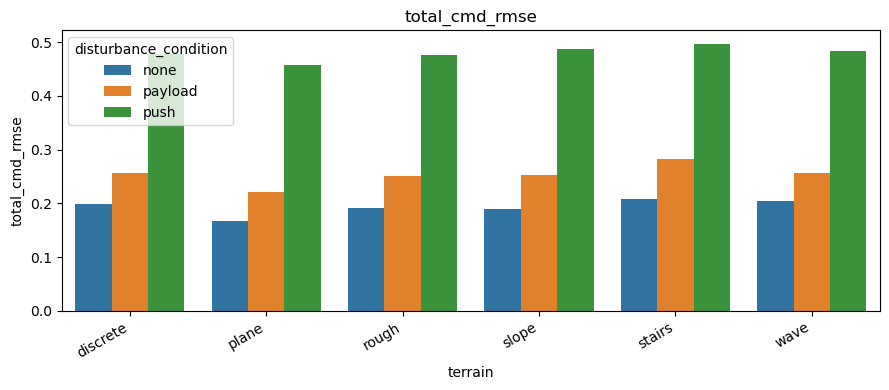

In [12]:
def plot_metric_by_terrain(results, metric, include_all=False):
    plot_df = results.copy()
    if not include_all:
        plot_df = plot_df[plot_df["terrain"] != "ALL"]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(9, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="disturbance_condition")
    else:
        for condition, group in plot_df.groupby("disturbance_condition"):
            plt.bar(group["terrain"], group[metric], label=condition)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


plot_metric_by_terrain(combined_results, "total_cmd_rmse")


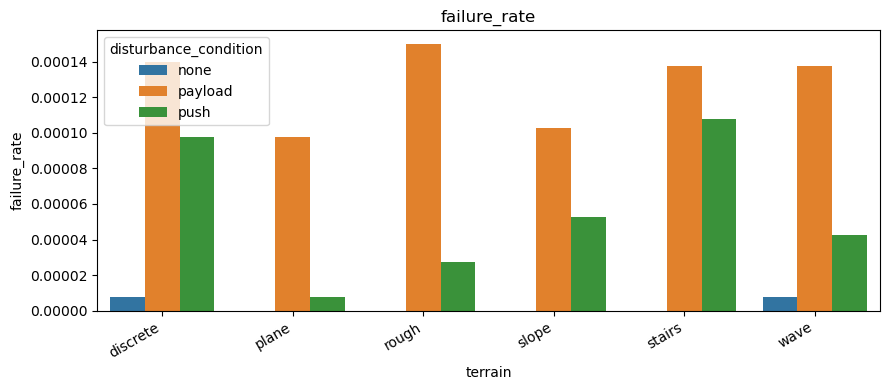

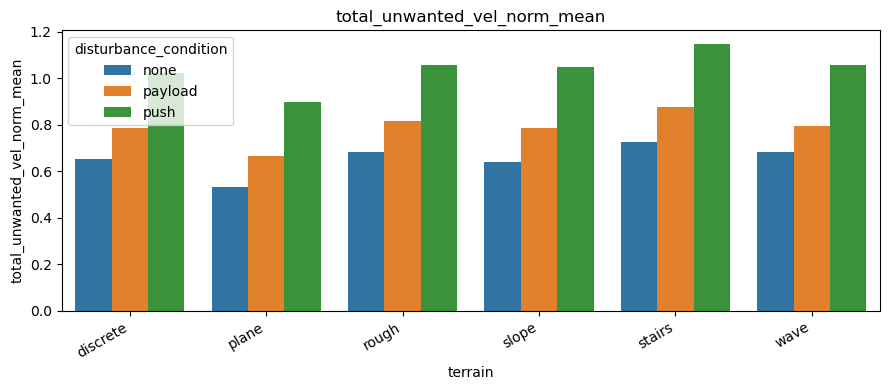

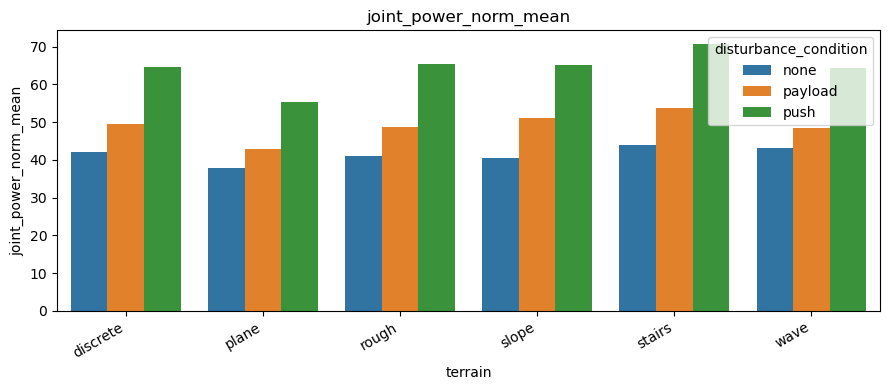

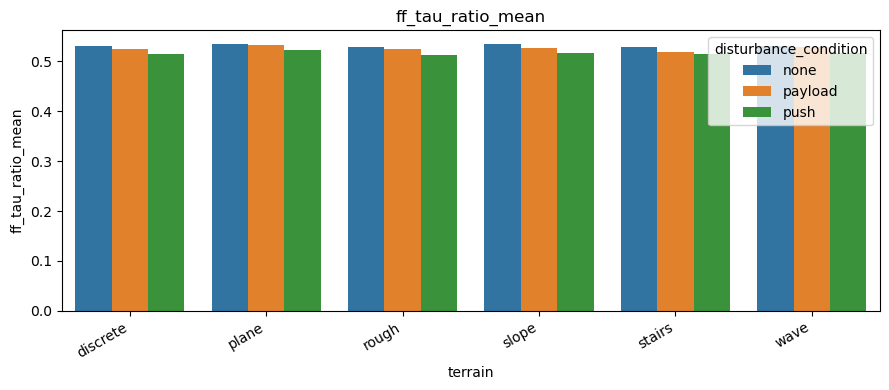

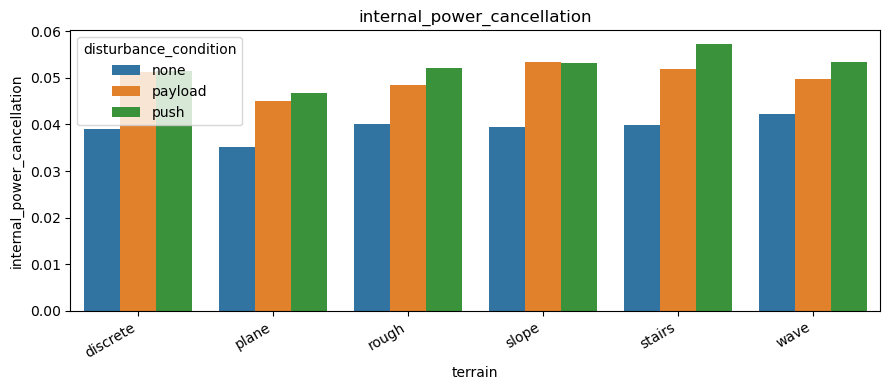

In [13]:
# Example additional plots
for metric in [
    "failure_rate",
    "total_unwanted_vel_norm_mean",
    "joint_power_norm_mean",
    "ff_tau_ratio_mean",
    "internal_power_cancellation",
]:
    if metric in combined_results.columns:
        plot_metric_by_terrain(combined_results, metric)


## Optional: compare multiple approaches

If you want to compare several approaches under the same experiment folder, set `APPROACHES` below and run the cell. It reuses the same functions above.


In [14]:
APPROACHES = ["pact"]  # e.g., ["pact", "pos", "tau"]

all_approach_dfs = []
for approach in APPROACHES:
    ft = find_eval_files(
        EXP_FOLDER,
        approach,
        disturbance_condition=DISTURBANCE_CONDITION,
    )
    if len(ft) == 0:
        print(f"No files found for approach: {approach}")
        continue

    all_approach_dfs.append(load_eval_dataset(ft))

if all_approach_dfs:
    df_multi = pd.concat(all_approach_dfs, ignore_index=True)

    multi_per_terrain = summarize_by_terrain(df_multi)
    multi_all_terrain = summarize_all_terrains(df_multi)
    multi_results = pd.concat([multi_per_terrain, multi_all_terrain], ignore_index=True)

    display(multi_results[[c for c in available_summary_cols if c in multi_results.columns]].round(4))
else:
    print("No approach files loaded.")


No files found for approach: pact
No approach files loaded.


In [15]:
def plot_metric_by_approach_and_terrain(results, metric, terrain_filter=None):
    plot_df = results.copy()

    if terrain_filter is not None:
        plot_df = plot_df[plot_df["terrain"].isin(terrain_filter)]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(10, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="approach")
    else:
        for approach, group in plot_df.groupby("approach"):
            plt.bar(group["terrain"], group[metric], label=approach)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


if "multi_results" in globals():
    plot_metric_by_approach_and_terrain(multi_results, "total_cmd_rmse")
